# Model klasyfikujący sekwencje

Klasyczny ML na cechach sekwencji:
- ekstrakcja cech z całej sekwencji (np. min/max/średnia/odchylenie dla
współrzędnych i prędkości, statystyki kątów),
- klasyfikator: SVM, Random Forest, Gradient Boosting itp.

⚠️ Należy (jednorazowo) doinstalować biblioteke scikit-learn:<br>

In [ ]:
%pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.9 MB 4.2 MB/s eta 0:00:02
   -------------- ------------------------- 3.1/8.9 MB 9.2 MB/s eta 0:00:01
   ------------------------ --------------- 5.5/8.9 MB 10.2 MB/s eta 0:00:01
   ----------------------------------- ---- 7.9/8.9 MB 10.4 MB/s eta 0:00:01
   ---------------------------------------- 8.9/8.9 MB 9.5 MB/s eta 0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- ----

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.model_selection import LeaveOneGroupOut, LeaveOneOut, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay, log_loss, recall_score, f1_score, precision_score
from sklearn.neural_network import MLPClassifier

### Wczytanie danych

In [3]:
data_path = '../data/dataset_urfall.npz'

if not os.path.exists(data_path):
    print(f"BŁĄD: Nie znaleziono pliku {data_path}")
else:
    print(f"Wczytuje dane z {data_path}...")
    with np.load(data_path) as data:
        sequences = data['sequences']
        X = data['X'] # znormalizowane punkty po preprocessingu
        y = data['y'] # etykiety (0 - stoi, 1 - leży)

    print(f"Wczytano {len(X)} próbek.")

print(f"\nKształt danych X (oryginalny): {X.shape}")
print(f"Kształt danych y: {y.shape}")
print(f"Liczba sekwencji: {len(np.unique(sequences))}")

# zmiana (N, 17, 2) -> (N, 34)
X = X.reshape(X.shape[0], -1)
print(f"\nKształt danych X (po reshape): {X.shape}")

Wczytuje dane z ../data/dataset_urfall.npz...
Wczytano 9627 próbek.

Kształt danych X (oryginalny): (9627, 17, 2)
Kształt danych y: (9627,)
Liczba sekwencji: 69

Kształt danych X (po reshape): (9627, 34)


# Walidacja modeli Leave-One-Group-Out

## Model Random Forest 🌲

In [4]:
# tablice do zbierania wyników
accuracies_rf = []
losses_rf = []
recalls_rf = []
all_y_trues_rf = []
all_y_preds_rf = []

# obiekt Leave-One-Group-Out (w skrócie LOGO)
LOGO = LeaveOneGroupOut()

print("Rozpoczęcie walidacji dla modelu RandomForest...")

for i, (train_idx, test_idx) in enumerate(tqdm(LOGO.split(X, y, sequences), total=len(np.unique(sequences)))):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # tworzenie i uczenie modelu
    rf_model = RandomForestClassifier(
        n_estimators=100,
        random_state=67,
        n_jobs=-1
        )
    rf_model.fit(X_train, y_train)

    # ewaluacja modelu (predykcje)
    y_pred_rf = rf_model.predict(X_test)
    # (prawdopodbieństwo)
    y_proba_rf = rf_model.predict_proba(X_test)

    # miary jakości modelu
    rf_acc = accuracy_score(y_test, y_pred_rf)
    accuracies_rf.append(rf_acc)
    # log loss
    rf_loss = log_loss(y_test, y_proba_rf, labels=[0, 1])
    losses_rf.append(rf_loss)
    # recall
    rf_recall = recall_score(y_test, y_pred_rf, pos_label=1, zero_division=0)
    recalls_rf.append(rf_recall)

    current_seq_name = sequences[test_idx][0]

    print(f"\n   Wideo: {current_seq_name}")
    print(f"   Acc: {rf_acc:.3f} | Loss: {rf_loss:.3f} | Recall: {rf_recall:.3f}")

    all_y_trues_rf.extend(y_test)
    all_y_preds_rf.extend(y_pred_rf)

print("\nWalidacja zakończona.")

Rozpoczęcie walidacji dla modelu RandomForest...


  1%|▏         | 1/69 [00:02<02:23,  2.10s/it]


   Wideo: adl-01
   Acc: 0.938 | Loss: 0.129 | Recall: 0.000


  3%|▎         | 2/69 [00:04<02:23,  2.14s/it]


   Wideo: adl-02
   Acc: 0.987 | Loss: 0.120 | Recall: 0.000


...


   Wideo: fall-28
   Acc: 1.000 | Loss: 0.022 | Recall: 1.000


 99%|█████████▊| 68/69 [02:24<00:02,  2.37s/it]


   Wideo: fall-29
   Acc: 1.000 | Loss: 0.015 | Recall: 1.000


100%|██████████| 69/69 [02:25<00:00,  2.11s/it]


   Wideo: fall-30
   Acc: 1.000 | Loss: 0.046 | Recall: 1.000

Walidacja zakończona.


### Wyniki

==================== Random Forest ====================
Średnia dokładnośc (accuracy): 0.967
Średni Log Loss:  0.110
Średni Recall:    0.610

Raport zbiorczy (z wszystkich testów):

              precision    recall  f1-score   support

        Stoi       0.97      0.97      0.97      7330
        Leży       0.90      0.90      0.90      2297

    accuracy                           0.95      9627
   macro avg       0.94      0.93      0.93      9627
weighted avg       0.95      0.95      0.95      9627



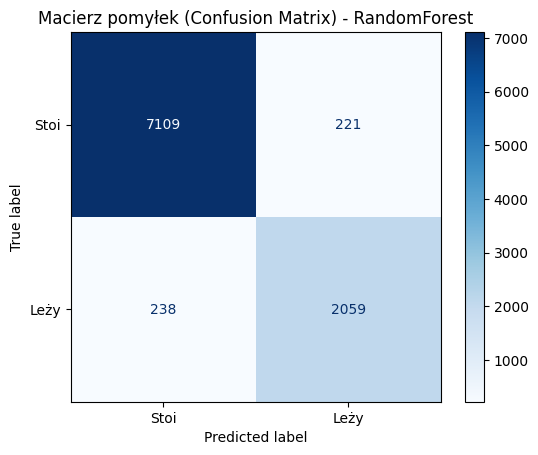

In [5]:
print(f"="*20+" Random Forest "+"="*20)

print(f"Średnia dokładnośc (accuracy): {np.mean(accuracies_rf):.3f}")
print(f"Średni Log Loss:  {np.mean(losses_rf):.3f}")
print(f"Średni Recall:    {np.mean(recalls_rf):.3f}")

print(f"\nRaport zbiorczy (z wszystkich testów):\n")
print(classification_report(all_y_trues_rf, all_y_preds_rf, target_names=['Stoi', 'Leży']))

# macierz pomyłek
cm_rf = confusion_matrix(all_y_trues_rf, all_y_preds_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=['Stoi', 'Leży']).plot(cmap='Blues')
plt.title(f'Macierz pomyłek (Confusion Matrix) - RandomForest')
plt.show()

## Model SVM 📐

In [6]:
# tablice do zbierania wyników
accuracies_svm = []
losses_svm = []
recalls_svm = []
all_y_trues_svm = []
all_y_preds_svm= []

# obiekt Leave-One-Group-Out (w skrócie LOGO)
LOGO = LeaveOneGroupOut()

print("Rozpoczęcie walidacji dla modelu SVM...")

for i, (train_idx, test_idx) in enumerate(tqdm(LOGO.split(X, y, sequences), total=len(np.unique(sequences)))):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # tworzenie i uczenie modelu
    svm_model = SVC(
        C=1,
        kernel='rbf',
        probability=True,
        random_state=67
        )
    svm_model.fit(X_train, y_train)

    # ewaluacja modelu (predykcje)
    y_pred_svm = svm_model.predict(X_test)
    # (prawdopodobienstwo)
    y_proba_svm = svm_model.predict_proba(X_test)

    # miary jakości modelu
    svm_acc = accuracy_score(y_test, y_pred_svm)
    accuracies_svm.append(svm_acc)
    # log loss
    svm_loss = log_loss(y_test, y_proba_svm, labels=[0, 1])
    losses_svm.append(svm_loss)
    # recall
    svm_recall = recall_score(y_test, y_pred_svm, pos_label=1, zero_division=0)
    recalls_svm.append(svm_recall)

    current_seq_name = sequences[test_idx][0]

    print(f"\n   Wideo: {current_seq_name}")
    print(f"   Acc: {svm_acc:.3f} | Loss: {svm_loss:.3f} | Recall: {svm_recall:.3f}\n")

    all_y_trues_svm.extend(y_test)
    all_y_preds_svm.extend(y_pred_svm)

print("\nWalidacja zakończona.")

Rozpoczęcie walidacji dla modelu SVM...


  1%|▏         | 1/69 [00:03<04:26,  3.92s/it]


   Wideo: adl-01
   Acc: 1.000 | Loss: 0.025 | Recall: 0.000



  3%|▎         | 2/69 [00:07<04:17,  3.84s/it]


   Wideo: adl-02
   Acc: 1.000 | Loss: 0.042 | Recall: 0.000



...


   Wideo: fall-28
   Acc: 1.000 | Loss: 0.005 | Recall: 1.000



 99%|█████████▊| 68/69 [04:29<00:03,  3.69s/it]


   Wideo: fall-29
   Acc: 1.000 | Loss: 0.001 | Recall: 1.000



100%|██████████| 69/69 [04:33<00:00,  3.97s/it]


   Wideo: fall-30
   Acc: 1.000 | Loss: 0.011 | Recall: 1.000


Walidacja zakończona.


### Wyniki

==================== SVM ====================
Średnia dokładnośc (accuracy):   0.973
Średni Log Loss:   0.088
Średni Recall:   0.601

Raport zbiorczy (z wszystkich testów): 

              precision    recall  f1-score   support

        Stoi       0.96      0.99      0.98      7330
        Leży       0.96      0.88      0.92      2297

    accuracy                           0.96      9627
   macro avg       0.96      0.93      0.95      9627
weighted avg       0.96      0.96      0.96      9627



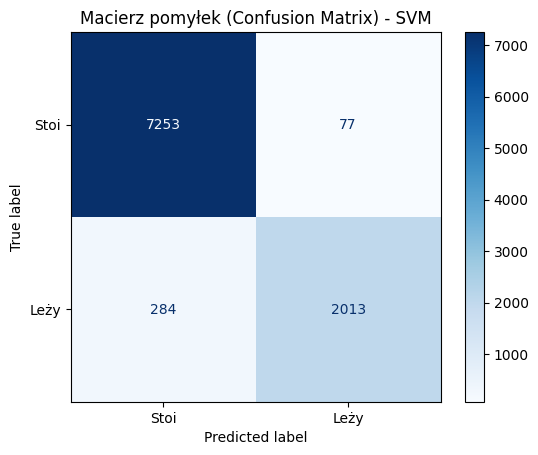

In [7]:
print(f"="*20+" SVM "+"="*20)

print(f"Średnia dokładnośc (accuracy):   {np.mean(accuracies_svm):.3f}")
print(f"Średni Log Loss:   {np.mean(losses_svm):.3f}")
print(f"Średni Recall:   {np.mean(recalls_svm):.3f}")

print(f"\nRaport zbiorczy (z wszystkich testów): \n")
print(classification_report(all_y_trues_svm, all_y_preds_svm, target_names=['Stoi', 'Leży']))

# macierz pomyłek
cm_svm = confusion_matrix(all_y_trues_svm, all_y_preds_svm)
ConfusionMatrixDisplay(cm_svm, display_labels=['Stoi', 'Leży']).plot(cmap='Blues')
plt.title(f'Macierz pomyłek (Confusion Matrix) - SVM')
plt.show()

## Model MLP 🧠

In [8]:
accuracies_mlp = []
recalls_mlp = []
losses_mlp = []
all_y_trues_mlp = []
all_y_preds_mlp = []

LOGO = LeaveOneGroupOut()

print("Rozpoczęcie walidacji dla modelu MLP...")

for i, (train_idx, test_idx) in enumerate(tqdm(LOGO.split(X, y, sequences), total=len(np.unique(sequences)))):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # tworzenie i uczenie modelu
    mlp_model = MLPClassifier(
        hidden_layer_sizes=(128),
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=67
        )
    mlp_model.fit(X_train, y_train)

    #
    y_pred_mlp = mlp_model.predict(X_test)

    #
    y_proba_mlp = mlp_model.predict_proba(X_test)

    # miary jakości
    mlp_acc = accuracy_score(y_test, y_pred_mlp)
    accuracies_mlp.append(mlp_acc)
    #
    mlp_loss = log_loss(y_test, y_proba_mlp, labels=[0, 1])
    losses_mlp.append(mlp_loss)
    #
    mlp_recall = recall_score(y_test, y_pred_mlp, pos_label=1, zero_division=0)
    recalls_mlp.append(mlp_recall)

    current_seq_name = sequences[test_idx][0]

    print(f"\n   Wideo: {current_seq_name}")
    print(f"   Acc: {mlp_acc:.3f} | Loss: {mlp_loss:.3f} | Recall: {mlp_recall:.3f}\n")

    all_y_trues_mlp.extend(y_test)
    all_y_preds_mlp.extend(y_pred_mlp)

print("\nWalidacja zakończona.")

Rozpoczęcie walidacji dla modelu MLP...


  1%|▏         | 1/69 [00:12<13:49, 12.19s/it]


   Wideo: adl-01
   Acc: 1.000 | Loss: 0.002 | Recall: 0.000



  3%|▎         | 2/69 [00:22<12:38, 11.32s/it]


   Wideo: adl-02
   Acc: 0.960 | Loss: 0.084 | Recall: 0.000



...


   Wideo: fall-28
   Acc: 1.000 | Loss: 0.000 | Recall: 1.000



 99%|█████████▊| 68/69 [13:08<00:12, 12.98s/it]


   Wideo: fall-29
   Acc: 1.000 | Loss: 0.000 | Recall: 1.000



100%|██████████| 69/69 [13:21<00:00, 11.62s/it]


   Wideo: fall-30
   Acc: 1.000 | Loss: 0.000 | Recall: 1.000


Walidacja zakończona.


### Wyniki

==================== MLP ====================
Średnia dokładnośc (accuracy):   0.968
Średni Log Loss:   0.152
Średni Recall:   0.595

Raport zbiorczy (z wszystkich testów):

              precision    recall  f1-score   support

        Stoi       0.96      0.98      0.97      7330
        Leży       0.95      0.87      0.90      2297

    accuracy                           0.96      9627
   macro avg       0.95      0.92      0.94      9627
weighted avg       0.96      0.96      0.96      9627



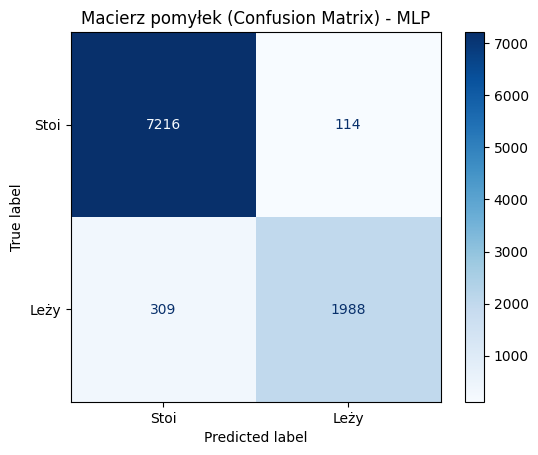

In [9]:
print(f"="*20+" MLP "+"="*20)

print(f"Średnia dokładnośc (accuracy):   {np.mean(accuracies_mlp):.3f}")
print(f"Średni Log Loss:   {np.mean(losses_mlp):.3f}")
print(f"Średni Recall:   {np.mean(recalls_mlp):.3f}")

print(f"\nRaport zbiorczy (z wszystkich testów):\n")
print(classification_report(all_y_trues_mlp, all_y_preds_mlp, target_names=['Stoi', 'Leży']))

# macierz pomyłek
cm_mlp = confusion_matrix(all_y_trues_mlp, all_y_preds_mlp)
ConfusionMatrixDisplay(cm_mlp, display_labels=['Stoi', 'Leży']).plot(cmap='Blues')
plt.title(f'Macierz pomyłek (Confusion Matrix) - MLP')
plt.show()

## Ogólne podsumowanie

In [10]:
from tabulate import tabulate

# Twoje dane
data = [
    ["Random Forest", round(np.mean(accuracies_rf), 3), round(np.mean(recalls_rf), 3), round(np.mean(losses_rf), 3)],
    ["SVM", round(np.mean(accuracies_svm), 3), round(np.mean(recalls_svm), 3), round(np.mean(losses_svm), 3)],
    ["MLP", round(np.mean(accuracies_mlp), 3), round(np.mean(recalls_mlp), 3), round(np.mean(losses_mlp), 3)]
]

# Nagłówki
headers = ["Model", "Accuracy", "Recall", "Losses"]

# Wyświetlenie (format 'fancy_grid' jest bardzo estetyczny)
print(tabulate(data, headers=headers, tablefmt="fancy_grid"))

╒═══════════════╤════════════╤══════════╤══════════╕
│ Model         │   Accuracy │   Recall │   Losses │
╞═══════════════╪════════════╪══════════╪══════════╡
│ Random Forest │      0.967 │    0.61  │    0.11  │
├───────────────┼────────────┼──────────┼──────────┤
│ SVM           │      0.973 │    0.601 │    0.088 │
├───────────────┼────────────┼──────────┼──────────┤
│ MLP           │      0.968 │    0.595 │    0.152 │
╘═══════════════╧════════════╧══════════╧══════════╛


# Walidacja modeli Leave-One-Out po agregacji cech

### Wczytanie danych

In [11]:
data_path_2 = '../data/dataset_urfall_fe.npz'

if not os.path.exists(data_path_2):
    print(f"BŁĄD: Nie znaleziono pliku {data_path_2}")
else:
    print(f"Wczytuje dane z {data_path_2}...")
    with np.load(data_path_2) as data_2:
        sequences = data_2['sequences']
        X = data_2['X'] # sekwencje po agregacji cech
        y = data_2['y'] # etykiety (0 - ADL, 1 - Fall)

    print(f"Wczytano {len(X)} próbek.")

print(f"\nKształt danych X (oryginalny): {X.shape}")
print(f"Kształt danych y: {y.shape}")
print(f"Liczba sekwencji: {len(np.unique(sequences))}")

# zmiana (N, 136, 2) -> (N, 272)
X = X.reshape(X.shape[0], -1)
print(f"\nKształt danych X (po reshape): {X.shape}")

Wczytuje dane z ../data/dataset_urfall_fe.npz...
Wczytano 45 próbek.

Kształt danych X (oryginalny): (45, 136, 2)
Kształt danych y: (45,)
Liczba sekwencji: 45

Kształt danych X (po reshape): (45, 272)


## Model Random Forest 🌲

In [12]:
# tablice do zbierania wyników
accuracies_rf = []
losses_rf = []
recalls_rf = []
all_y_trues_rf = []
all_y_preds_rf = []

# obiekt Leave-One-Out (w skrócie LOO)
LOO = LeaveOneOut()

print("Rozpoczęcie walidacji LOO dla modelu RandomForest...")

for train_idx, test_idx in tqdm(LOO.split(X), total=len(X)):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # tworzenie i uczenie modelu
    rf_model = RandomForestClassifier(
        n_estimators=100,
        random_state=67,
        n_jobs=-1
        )
    rf_model.fit(X_train, y_train)

    # ewaluacja modelu (predykcje)
    y_pred_rf = rf_model.predict(X_test)
    # (prawdopodbieństwo)
    y_proba_rf = rf_model.predict_proba(X_test)

    # miary jakości modelu
    rf_acc = accuracy_score(y_test, y_pred_rf)
    accuracies_rf.append(rf_acc)
    # log loss
    rf_loss = log_loss(y_test, y_proba_rf, labels=[0, 1])
    losses_rf.append(rf_loss)
    # recall
    rf_recall = recall_score(y_test, y_pred_rf, pos_label=1, zero_division=0)
    recalls_rf.append(rf_recall)

    current_seq_name = sequences[test_idx][0]

    print(f"\n   Wideo: {current_seq_name}")
    print(f"   Acc: {rf_acc:.3f} | Loss: {rf_loss:.3f} | Recall: {rf_recall:.3f}")

    all_y_trues_rf.extend(y_test)
    all_y_preds_rf.extend(y_pred_rf)

print("\nWalidacja zakończona.")

Rozpoczęcie walidacji LOO dla modelu RandomForest...


  2%|▏         | 1/45 [00:00<00:28,  1.53it/s]


   Wideo: adl-10
   Acc: 0.000 | Loss: 1.050 | Recall: 0.000


  4%|▍         | 2/45 [00:00<00:19,  2.25it/s]


   Wideo: adl-11
   Acc: 0.000 | Loss: 0.942 | Recall: 0.000


...


   Wideo: fall-28
   Acc: 1.000 | Loss: 0.094 | Recall: 1.000


 98%|█████████▊| 44/45 [00:13<00:00,  3.01it/s]


   Wideo: fall-29
   Acc: 1.000 | Loss: 0.151 | Recall: 1.000


100%|██████████| 45/45 [00:13<00:00,  3.22it/s]


   Wideo: fall-30
   Acc: 1.000 | Loss: 0.105 | Recall: 1.000

Walidacja zakończona.


### Wyniki

==================== Random Forest ====================
Średnia dokładnośc (accuracy): 0.933
Średni Log Loss:  0.320
Średni Recall:    0.644

Raport zbiorczy (z wszystkich testów):

              precision    recall  f1-score   support

         ADL       0.93      0.87      0.90        15
        FALL       0.94      0.97      0.95        30

    accuracy                           0.93        45
   macro avg       0.93      0.92      0.92        45
weighted avg       0.93      0.93      0.93        45



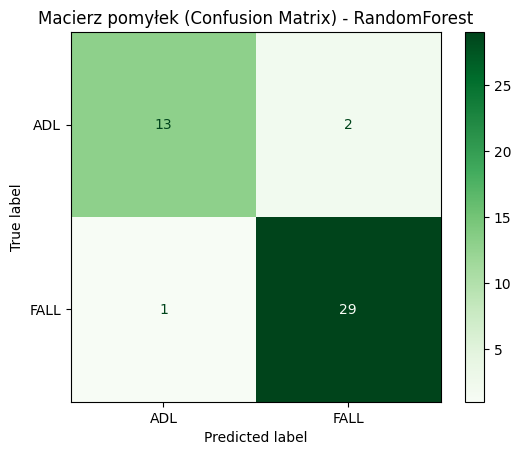

In [13]:
print(f"="*20+" Random Forest "+"="*20)

print(f"Średnia dokładnośc (accuracy): {np.mean(accuracies_rf):.3f}")
print(f"Średni Log Loss:  {np.mean(losses_rf):.3f}")
print(f"Średni Recall:    {np.mean(recalls_rf):.3f}")

print(f"\nRaport zbiorczy (z wszystkich testów):\n")
print(classification_report(all_y_trues_rf, all_y_preds_rf, target_names=['ADL', 'FALL']))

# macierz pomyłek
cm_rf = confusion_matrix(all_y_trues_rf, all_y_preds_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=['ADL', 'FALL']).plot(cmap='Greens')
plt.title(f'Macierz pomyłek (Confusion Matrix) - RandomForest')
plt.show()

## Model SVM 📐

In [14]:
# tablice do zbierania wyników
accuracies_svm = []
losses_svm = []
recalls_svm = []
all_y_trues_svm = []
all_y_preds_svm= []

# obiekt Leave-One-Out (w skrócie LOO)
LOO = LeaveOneOut()

print("Rozpoczęcie walidacji LOO dla modelu SVM...")

for train_idx, test_idx in tqdm(LOO.split(X), total=len(X)):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # tworzenie i uczenie modelu
    svm_model = SVC(
        C=1,
        kernel='rbf',
        probability=True,
        random_state=67
        )
    svm_model.fit(X_train, y_train)

    # ewaluacja modelu (predykcje)
    y_pred_svm = svm_model.predict(X_test)
    # (prawdopodobienstwo)
    y_proba_svm = svm_model.predict_proba(X_test)

    # miary jakości modelu
    svm_acc = accuracy_score(y_test, y_pred_svm)
    accuracies_svm.append(svm_acc)
    # log loss
    svm_loss = log_loss(y_test, y_proba_svm, labels=[0, 1])
    losses_svm.append(svm_loss)
    # recall
    svm_recall = recall_score(y_test, y_pred_svm, pos_label=1, zero_division=0)
    recalls_svm.append(svm_recall)

    current_seq_name = sequences[test_idx][0]

    print(f"\n   Wideo: {current_seq_name}")
    print(f"   Acc: {svm_acc:.3f} | Loss: {svm_loss:.3f} | Recall: {svm_recall:.3f}\n")

    all_y_trues_svm.extend(y_test)
    all_y_preds_svm.extend(y_pred_svm)

print("\nWalidacja zakończona.")

Rozpoczęcie walidacji LOO dla modelu SVM...


 47%|████▋     | 21/45 [00:00<00:00, 101.84it/s]


   Wideo: adl-10
   Acc: 0.000 | Loss: 1.177 | Recall: 0.000


   Wideo: adl-11
   Acc: 0.000 | Loss: 2.439 | Recall: 0.000


   Wideo: adl-21
   Acc: 1.000 | Loss: 0.325 | Recall: 0.000


   Wideo: adl-22
   Acc: 1.000 | Loss: 0.122 | Recall: 0.000


   Wideo: adl-30
   Acc: 1.000 | Loss: 0.260 | Recall: 0.000


   Wideo: adl-31
   Acc: 1.000 | Loss: 0.132 | Recall: 0.000


   Wideo: adl-32
   Acc: 1.000 | Loss: 0.063 | Recall: 0.000


   Wideo: adl-33
   Acc: 1.000 | Loss: 0.075 | Recall: 0.000


   Wideo: adl-34
   Acc: 1.000 | Loss: 0.209 | Recall: 0.000


   Wideo: adl-35
   Acc: 1.000 | Loss: 0.180 | Recall: 0.000


   Wideo: adl-36
   Acc: 0.000 | Loss: 1.175 | Recall: 0.000


   Wideo: adl-37
   Acc: 0.000 | Loss: 1.907 | Recall: 0.000


   Wideo: adl-38
   Acc: 1.000 | Loss: 0.255 | Recall: 0.000


   Wideo: adl-39
   Acc: 1.000 | Loss: 0.073 | Recall: 0.000


   Wideo: adl-40
   Acc: 1.000 | Loss: 0.068 | Recall: 0.000


   Wideo: fall-01
   Acc: 0.000 | Loss: 0.995 | Recall

 71%|███████   | 32/45 [00:00<00:00, 105.12it/s]


   Wideo: fall-07
   Acc: 1.000 | Loss: 0.043 | Recall: 1.000


   Wideo: fall-08
   Acc: 1.000 | Loss: 0.099 | Recall: 1.000


   Wideo: fall-09
   Acc: 1.000 | Loss: 0.090 | Recall: 1.000


   Wideo: fall-10
   Acc: 1.000 | Loss: 0.075 | Recall: 1.000


   Wideo: fall-11
   Acc: 1.000 | Loss: 0.089 | Recall: 1.000


   Wideo: fall-12
   Acc: 1.000 | Loss: 0.070 | Recall: 1.000


   Wideo: fall-13
   Acc: 1.000 | Loss: 0.217 | Recall: 1.000


   Wideo: fall-14
   Acc: 1.000 | Loss: 0.077 | Recall: 1.000


   Wideo: fall-15
   Acc: 1.000 | Loss: 0.055 | Recall: 1.000


   Wideo: fall-16
   Acc: 1.000 | Loss: 0.040 | Recall: 1.000


   Wideo: fall-17
   Acc: 1.000 | Loss: 0.365 | Recall: 1.000


   Wideo: fall-18
   Acc: 1.000 | Loss: 0.225 | Recall: 1.000


   Wideo: fall-19
   Acc: 0.000 | Loss: 0.753 | Recall: 0.000


   Wideo: fall-20
   Acc: 1.000 | Loss: 0.049 | Recall: 1.000


   Wideo: fall-21
   Acc: 1.000 | Loss: 0.082 | Recall: 1.000


   Wideo: fall-22
   Acc: 1.000 | Loss:

100%|██████████| 45/45 [00:00<00:00, 106.34it/s]


   Wideo: fall-29
   Acc: 1.000 | Loss: 0.133 | Recall: 1.000


   Wideo: fall-30
   Acc: 1.000 | Loss: 0.299 | Recall: 1.000


Walidacja zakończona.


### Wyniki

==================== SVM ====================
Średnia dokładnośc (accuracy):   0.844
Średni Log Loss:   0.325
Średni Recall:   0.600

Raport zbiorczy (z wszystkich testów): 

              precision    recall  f1-score   support

         ADL       0.79      0.73      0.76        15
        FALL       0.87      0.90      0.89        30

    accuracy                           0.84        45
   macro avg       0.83      0.82      0.82        45
weighted avg       0.84      0.84      0.84        45



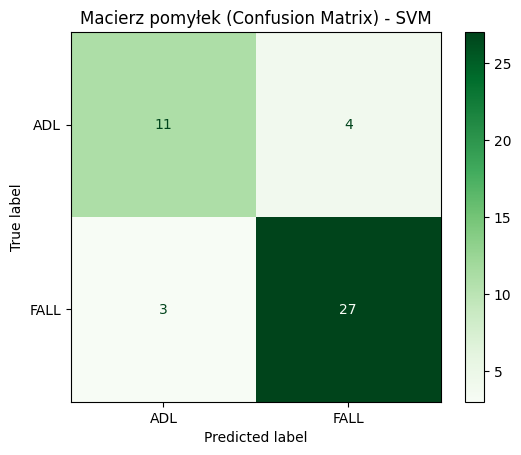

In [15]:
print(f"="*20+" SVM "+"="*20)

print(f"Średnia dokładnośc (accuracy):   {np.mean(accuracies_svm):.3f}")
print(f"Średni Log Loss:   {np.mean(losses_svm):.3f}")
print(f"Średni Recall:   {np.mean(recalls_svm):.3f}")

print(f"\nRaport zbiorczy (z wszystkich testów): \n")
print(classification_report(all_y_trues_svm, all_y_preds_svm, target_names=['ADL', 'FALL']))

# macierz pomyłek
cm_svm = confusion_matrix(all_y_trues_svm, all_y_preds_svm)
ConfusionMatrixDisplay(cm_svm, display_labels=['ADL', 'FALL']).plot(cmap='Greens')
plt.title(f'Macierz pomyłek (Confusion Matrix) - SVM')
plt.show()

## Model MLP 🧠

In [16]:
accuracies_mlp = []
recalls_mlp = []
losses_mlp = []
all_y_trues_mlp = []
all_y_preds_mlp = []

LOO = LeaveOneOut()

print("Rozpoczęcie walidacji LOO dla modelu MLP...")

for train_idx, test_idx in tqdm(LOO.split(X), total=len(X)):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # tworzenie i uczenie modelu
    mlp_model = MLPClassifier(
        hidden_layer_sizes=(128),
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=67
        )
    mlp_model.fit(X_train, y_train)

    #
    y_pred_mlp = mlp_model.predict(X_test)

    #
    y_proba_mlp = mlp_model.predict_proba(X_test)

    # miary jakości
    mlp_acc = accuracy_score(y_test, y_pred_mlp)
    accuracies_mlp.append(mlp_acc)
    #
    mlp_loss = log_loss(y_test, y_proba_mlp, labels=[0, 1])
    losses_mlp.append(mlp_loss)
    #
    mlp_recall = recall_score(y_test, y_pred_mlp, pos_label=1, zero_division=0)
    recalls_mlp.append(mlp_recall)

    current_seq_name = sequences[test_idx][0]

    print(f"\n   Wideo: {current_seq_name}")
    print(f"   Acc: {mlp_acc:.3f} | Loss: {mlp_loss:.3f} | Recall: {mlp_recall:.3f}\n")

    all_y_trues_mlp.extend(y_test)
    all_y_preds_mlp.extend(y_pred_mlp)

print("\nWalidacja zakończona.")

Rozpoczęcie walidacji LOO dla modelu MLP...


  2%|▏         | 1/45 [00:00<00:12,  3.59it/s]


   Wideo: adl-10
   Acc: 1.000 | Loss: 0.006 | Recall: 0.000



  4%|▍         | 2/45 [00:00<00:15,  2.72it/s]


   Wideo: adl-11
   Acc: 0.000 | Loss: 2.310 | Recall: 0.000



...


   Wideo: fall-28
   Acc: 1.000 | Loss: 0.000 | Recall: 1.000



 98%|█████████▊| 44/45 [00:12<00:00,  3.92it/s]


   Wideo: fall-29
   Acc: 1.000 | Loss: 0.002 | Recall: 1.000



100%|██████████| 45/45 [00:12<00:00,  3.57it/s]


   Wideo: fall-30
   Acc: 1.000 | Loss: 0.000 | Recall: 1.000


Walidacja zakończona.


### Wyniki

==================== MLP ====================
Średnia dokładnośc (accuracy):   0.844
Średni Log Loss:   0.333
Średni Recall:   0.578

Raport zbiorczy (z wszystkich testów):

              precision    recall  f1-score   support

         ADL       0.75      0.80      0.77        15
        FALL       0.90      0.87      0.88        30

    accuracy                           0.84        45
   macro avg       0.82      0.83      0.83        45
weighted avg       0.85      0.84      0.85        45



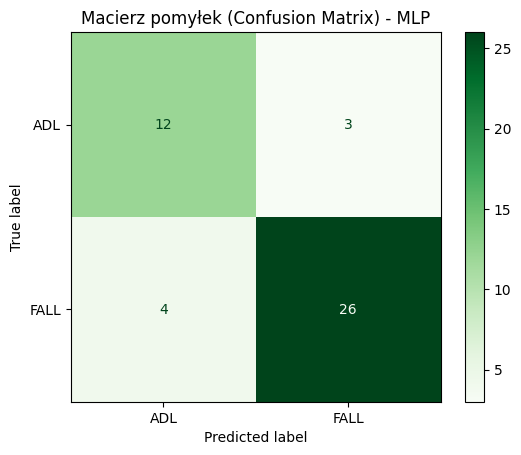

In [17]:
print(f"="*20+" MLP "+"="*20)

print(f"Średnia dokładnośc (accuracy):   {np.mean(accuracies_mlp):.3f}")
print(f"Średni Log Loss:   {np.mean(losses_mlp):.3f}")
print(f"Średni Recall:   {np.mean(recalls_mlp):.3f}")

print(f"\nRaport zbiorczy (z wszystkich testów):\n")
print(classification_report(all_y_trues_mlp, all_y_preds_mlp, target_names=['ADL', 'FALL']))

# macierz pomyłek
cm_mlp = confusion_matrix(all_y_trues_mlp, all_y_preds_mlp)
ConfusionMatrixDisplay(cm_mlp, display_labels=['ADL', 'FALL']).plot(cmap='Greens')
plt.title(f'Macierz pomyłek (Confusion Matrix) - MLP')
plt.show()

## Ogólne podsumowanie

In [18]:
from tabulate import tabulate

# Twoje dane
data = [
    ["Random Forest", round(np.mean(accuracies_rf), 3), round(np.mean(recalls_rf), 3), round(np.mean(losses_rf), 3)],
    ["SVM", round(np.mean(accuracies_svm), 3), round(np.mean(recalls_svm), 3), round(np.mean(losses_svm), 3)],
    ["MLP", round(np.mean(accuracies_mlp), 3), round(np.mean(recalls_mlp), 3), round(np.mean(losses_mlp), 3)]
]

# Nagłówki
headers = ["Model", "Accuracy", "Recall", "Losses"]

# Wyświetlenie (format 'fancy_grid' jest bardzo estetyczny)
print(tabulate(data, headers=headers, tablefmt="fancy_grid"))

╒═══════════════╤════════════╤══════════╤══════════╕
│ Model         │   Accuracy │   Recall │   Losses │
╞═══════════════╪════════════╪══════════╪══════════╡
│ Random Forest │      0.933 │    0.644 │    0.32  │
├───────────────┼────────────┼──────────┼──────────┤
│ SVM           │      0.844 │    0.6   │    0.325 │
├───────────────┼────────────┼──────────┼──────────┤
│ MLP           │      0.844 │    0.578 │    0.333 │
╘═══════════════╧════════════╧══════════╧══════════╛
